# Walmart Location, Sales, and Population Analysis

 A cleaned version of the original notebook. The goal is to answer a clearer question:

**How are Walmart and Sam's Club locations distributed across the United States, and how does that distribution compare with sales trends and state population?**

what drove this question well funny you should ask the idea came from personal experiece (before i was in ohio i came to texas and there i saw a lot of retail stores or restaurants and places some ive heard of over movies and different things about us culture while some i had no idea existed then when i moved from texas to ohio i found out huh that place isnt here there is something similar but not the same) so with this project i aim to see the topic like a question i imagined an investor that wants to know where to invest and his nose is leading him to walmart but where does this individual invest his money at ? which state? which branch of the walmart business ? which city? so this is where i started to answer questions i collected data from different sources some from the walmart website itself some from the SEC some from the government 



all imports and file paths are placed in one cell so the notebook is cleaner...ish

 if a CSV path changes, only this setup cell needs to be updated instead of searching through the whole notebook good coding practices. (the one i made before this was not clean at all)


In [37]:
from pathlib import Path
import math

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# The notebook first checks the folder where it is running.
# If the CSVs are not there, it uses the original class/project folder.
DATA_DIR_CANDIDATES = [
    Path.cwd(),
    Path(r"C:\Users\Rayamajhi Donald\indata_sp26"),
]

REQUIRED_FILES = {
    "stores": "STORE_STATUS_PUBLIC_VIEW_3007829193429392206.csv",
    "retail_sales": "RSXFS.csv",
    "weekly_sales": "Walmart_sales.csv",
    "sams_sales": "sams_club_net_sales_1991_current.csv",
    "walmart_us_sales": "walmart_us_net_sales_1991_current.csv",
    "population": "NST-EST2025-ALLDATA.csv",
}

DATA_DIR = next(
    (folder for folder in DATA_DIR_CANDIDATES if all((folder / file).exists() for file in REQUIRED_FILES.values())),
    None,
)


DATA_DIR

WindowsPath('c:/Users/Rayamajhi Donald/indata_sp26')

## 2. Load and Check the Store Dataset

 #before analyzing anything, we check the size, columns, missing values, and duplicate rows.

 #this prevents mistakes like charting the wrong column, counting duplicate stores, or using coordinates before checking their format (last one is important.)

In [38]:
stores_raw = pd.read_csv(DATA_DIR / REQUIRED_FILES["stores"])

print(f"Rows: {stores_raw.shape[0]:,}")
print(f"Columns: {stores_raw.shape[1]:,}")
print(f"Duplicate rows: {stores_raw.duplicated().sum():,}")

missing_summary = (
    stores_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_values")
)

missing_summary.head(10)

Rows: 5,209
Columns: 14
Duplicate rows: 0


,missing_values
County,1
OBJECTID,0
businessUnit_number,0
Description,0
Type,0
businessUnit_name,0
Address,0
City,0
State,0
Postal Code,0


In [39]:
stores_raw.head()

,OBJECTID,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,GlobalID,x,y
0,51077,"ROGERS, AR",1,WM Supercenter,Retail,2110 W WALNUT ST,ROGERS,BENTON,AR,72756-3246,Open,29e01211-412e-47e1-85e9-a4162a9680ca,-1.048062e+07,4.346304e+06
1,51078,HARRISON AR,2,WM Supercenter,Retail,161 N WALMART DR,HARRISON,BOONE,AR,72601-1960,Open,2e5c7c63-3469-4572-9713-e43b3554c329,-1.036820e+07,4.337694e+06
2,51079,COMMERCE GA,3,WM Supercenter,Retail,30983 HIGHWAY 441 S,COMMERCE,JACKSON,GA,30529-6655,Open,42a1faa5-f7aa-4b66-bd07-694501e68678,-9.290317e+06,4.062122e+06
3,51080,SILOAM SPRINGS AR,4,WM Supercenter,Retail,2901 HIGHWAY 412 E,SILOAM SPRINGS,BENTON,AR,72761-8673,Open,5ae6449c-7a76-4bb8-a574-fa89ad1c9dc5,-1.052109e+07,4.325893e+06
4,51081,CONWAY AR,5,WM Supercenter,Retail,1155 HWY 65 NORTH,CONWAY,FAULKNER,AR,72032-2857,Open,b195cb36-dc6c-481e-9149-5f07f3aa1d86,-1.029004e+07,4.178649e+06


## 3. Clean the Store Dataset

 the original file has extra columns and the coordinate columns are stored as projected map coordinates, not normal latitude and longitude (we need normal latitude and longitude to be able to put this all in a map).

 selecting useful columns makes the data easier to understand, and converting coordinates lets Plotly make a correct U.S. map.

In [ ]:
useful_store_columns = [
    "businessUnit_name",
    "businessUnit_number",
    "Description",
    "Type",
    "Address",
    "City",
    "County",
    "State",
    "Postal Code",
    "Operation Status",
    "x",
    "y",
]

stores = stores_raw[useful_store_columns].copy()

stores["State"] = stores["State"].astype(str).str.strip().str.upper()
stores["Type"] = stores["Type"].astype(str).str.strip()
stores["x"] = pd.to_numeric(stores["x"], errors="coerce")
stores["y"] = pd.to_numeric(stores["y"], errors="coerce")

# x/y are Web Mercator meters. Converting them to longitude/latitude for mapping. # 
earth_radius = 6378137
stores["longitude"] = stores["x"] / earth_radius * 180 / math.pi
stores["latitude"] = (2 * stores["y"].apply(lambda value: math.atan(math.exp(value / earth_radius))) - math.pi / 2) * 180 / math.pi

stores_clean = stores.dropna(subset=["State", "longitude", "latitude"]).copy()

# A few records have zero coordinates, which would place points far away from the U.S.
# Keep coordinates that fall inside a broad U.S. / territory bounding box.
valid_us_coordinates = ( 
    stores_clean["latitude"].between(17, 72)
    & stores_clean["longitude"].between(-180, -60)
)
stores_clean = stores_clean[valid_us_coordinates].copy()

stores_clean.head()


,businessUnit_name,businessUnit_number,Description,Type,Address,City,County,State,Postal Code,Operation Status,x,y,longitude,latitude
0,"ROGERS, AR",1,WM Supercenter,Retail,2110 W WALNUT ST,ROGERS,BENTON,AR,72756-3246,Open,-1.048062e+07,4.346304e+06,-94.149054,36.331300
1,HARRISON AR,2,WM Supercenter,Retail,161 N WALMART DR,HARRISON,BOONE,AR,72601-1960,Open,-1.036820e+07,4.337694e+06,-93.139134,36.268968
2,COMMERCE GA,3,WM Supercenter,Retail,30983 HIGHWAY 441 S,COMMERCE,JACKSON,GA,30529-6655,Open,-9.290317e+06,4.062122e+06,-83.456336,34.247784
3,SILOAM SPRINGS AR,4,WM Supercenter,Retail,2901 HIGHWAY 412 E,SILOAM SPRINGS,BENTON,AR,72761-8673,Open,-1.052109e+07,4.325893e+06,-94.512546,36.183446
4,CONWAY AR,5,WM Supercenter,Retail,1155 HWY 65 NORTH,CONWAY,FAULKNER,AR,72032-2857,Open,-1.029004e+07,4.178649e+06,-92.437042,35.108595


In [41]:
store_summary = pd.DataFrame({
    "metric": [
        "Total store records",
        "States/territories represented",
        "Store types",
        "Open locations",
    ],
    "value": [
        len(stores_clean),
        stores_clean["State"].nunique(),
        stores_clean["Type"].nunique(),
        (stores_clean["Operation Status"].str.lower() == "open").sum(),
    ],
})

store_summary

,metric,value
0,Total store records,5208
1,States/territories represented,52
2,Store types,2
3,Open locations,5206


## 4. Store Counts by State and Type

How many stores are there in any one specific state? counting stores by state shows where Walmart has the biggest physical footprint. this gives a simple starting point before comparing locations with anything else

In [42]:
state_counts = (
    stores_clean["State"]
    .value_counts()
    .rename_axis("State")
    .reset_index(name="store_count")
)

state_counts.head(10)

,State,store_count
0,TX,590
1,FL,386
2,CA,303
3,NC,214
4,GA,210
5,IL,177
6,OH,170
7,PA,159
8,MO,156
9,TN,150


# okay so looks like texas has the higher number of stores however is it where the investor should put his money? lets look further...

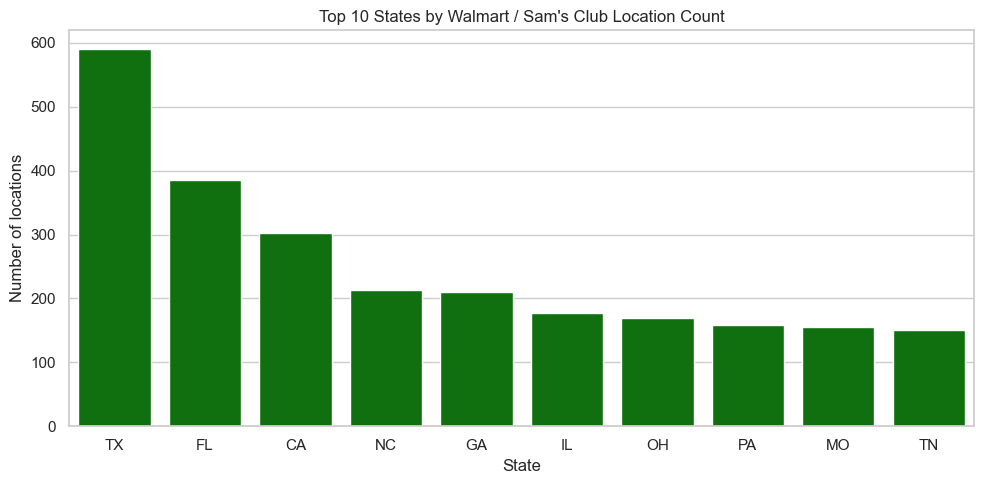

In [62]:
plt.figure(figsize=(10, 5))
sns.barplot(data=state_counts.head(10), x="State", y="store_count", color="green")
plt.title("Top 10 States by Walmart / Sam's Club Location Count")
plt.xlabel("State")
plt.ylabel("Number of locations")
plt.tight_layout()
plt.show()

In [51]:

type_counts = stores_clean["Type"].value_counts().reset_index()
type_counts.columns = ["store_type", "count"]

fig = px.bar(
    type_counts,
    x="store_type",
    y="count",
    color="store_type",
    text="count",
    title="Locations by Store Type",
    labels={
        "store_type": "Store Type",
        "count": "Number of Locations"
    }
)

fig.update_traces(
    hovertemplate=(
        "Store Type : %{x}<br>"
        "Locations : %{y:,}"
        "<extra></extra>"
    )
)

fig.show()

In [52]:
fig = px.pie(
    type_counts,
    names="store_type",
    values="count",
    title="Share of Locations by Type"
)

fig.update_traces(
    hovertemplate=(
        "Store Type : %{label}<br>"
        "Locations : %{value:,}<br>"
        "Share : %{percent}"
        "<extra></extra>"
    )
)

fig.show()

## 5. Map Store Locations

 Now lets make a map is better than a table for seeing geographic spread. it shows that Walmart's footprint is national, but it also makes regional clusters easier to notice maybe the stores in any one state are not that spread out? could be but this helps us visualize it

In [49]:
ffig = px.scatter_geo(
    stores_clean,
    lat="latitude",
    lon="longitude",
    hover_name="businessUnit_name",
    custom_data=["Type", "Description", "Address", "City", "State"],
    color="Type",
    scope="usa",
    title="Walmart and Sam's Club Locations in the United States",
    height=650,
)

fig.update_traces(
    marker=dict(size=4, opacity=0.65),
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Type : %{customdata[0]}<br>"
        "Name : %{customdata[1]}<br>"
        "Address : %{customdata[2]}<br>"
        "City : %{customdata[3]}<br>"
        "State : %{customdata[4]}"
        "<extra></extra>"
    )
)

fig.update_layout(legend_title_text="Store Type")

fig.show()

## 6. U.S. Retail Sales Over Time

now that we know where the stores are lets use the RSXFS dataset that gives a national retail sales trend, which gives context for Walmart's business environment instead of only looking at store counts, this shows whether the overall retail market has been growing over time.

In [46]:
retail_sales = pd.read_csv(DATA_DIR / REQUIRED_FILES["retail_sales"])
retail_sales = retail_sales.rename(columns={"observation_date": "date", "RSXFS": "retail_sales"})
retail_sales["date"] = pd.to_datetime(retail_sales["date"])
retail_sales["retail_sales"] = pd.to_numeric(retail_sales["retail_sales"], errors="coerce")
retail_sales = retail_sales.dropna().sort_values("date")

retail_sales.head()

,date,retail_sales
0,1992-01-01,142419
1,1992-02-01,142584
2,1992-03-01,142120
3,1992-04-01,143659
4,1992-05-01,144239


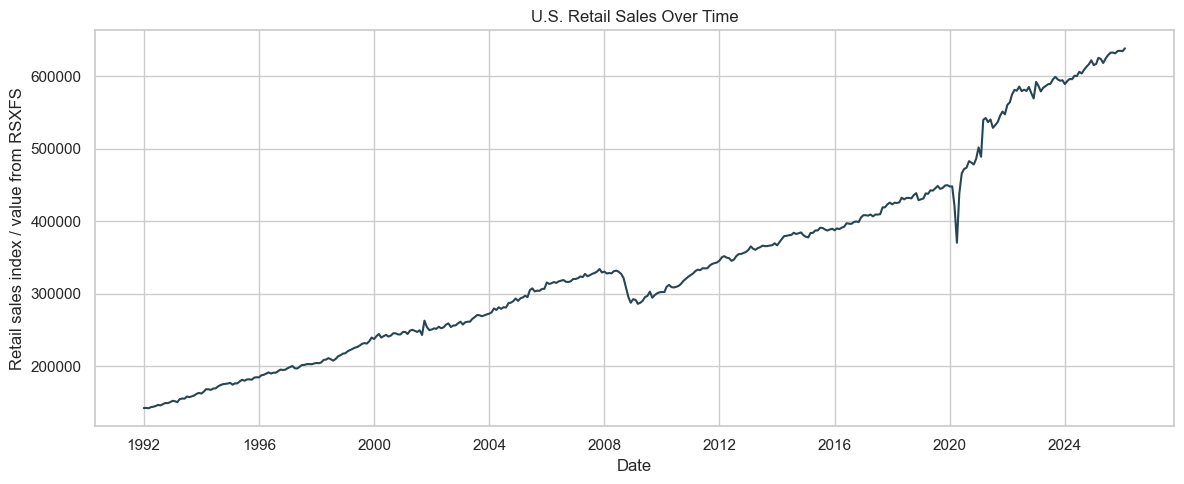

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(retail_sales["date"], retail_sales["retail_sales"], color="#264653")
plt.title("U.S. Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Retail sales index / value from RSXFS")
plt.tight_layout()
plt.show()

# what is it? this shows the us retail sales over time meaning all the retail sales so by logic walmart and other retail stores should follow the same trend or close to it.



## 8. Walmart U.S. vs. Sam's Club Net Sales

walmart itself has 2 branches it sells products first walmart the next sams for wholesale the location dataset separates Retail and Sam's Club store types, so the sales section should also separate Walmart U.S. and Sam's Club when possible as even though its part of the same business its 2 distinct way of selling and 2 different stores.


In [56]:
sams_sales = pd.read_csv(DATA_DIR / REQUIRED_FILES["sams_sales"])
walmart_us_sales = pd.read_csv(DATA_DIR / REQUIRED_FILES["walmart_us_sales"])

segment_sales = pd.concat([sams_sales, walmart_us_sales], ignore_index=True)
segment_sales = segment_sales.dropna(subset=["net_sales_billions_usd"]).copy()
segment_sales["fiscal_year_end_year"] = segment_sales["fiscal_year_end_year"].astype(int)
segment_sales = segment_sales.sort_values(["segment", "fiscal_year_end_year"])

segment_sales[["fiscal_year_end_year", "segment", "net_sales_billions_usd", "yoy_change_percent"]].tail(10)

,fiscal_year_end_year,segment,net_sales_billions_usd,yoy_change_percent
62,2017,Walmart U.S.,307.833,3.17
63,2018,Walmart U.S.,318.477,3.46
64,2019,Walmart U.S.,331.666,4.14
65,2020,Walmart U.S.,341.004,2.82
66,2021,Walmart U.S.,369.963,8.49
67,2022,Walmart U.S.,393.247,6.29
68,2023,Walmart U.S.,420.553,6.94
69,2024,Walmart U.S.,441.817,5.06
70,2025,Walmart U.S.,462.415,4.66
71,2026,Walmart U.S.,482.975,4.45


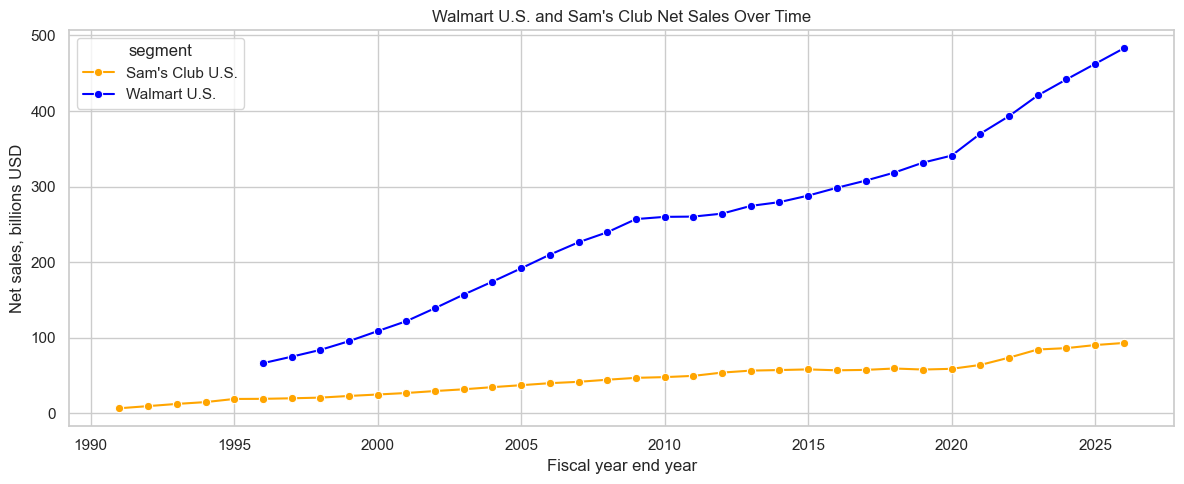

In [59]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=segment_sales,
    x="fiscal_year_end_year",
    y="net_sales_billions_usd",
    hue="segment",
    marker="o",
    palette={
        "Sam's Club U.S.": "orange",
        "Walmart U.S.": "blue"
    }
)

plt.title("Walmart U.S. and Sam's Club Net Sales Over Time")
plt.xlabel("Fiscal year end year")
plt.ylabel("Net sales, billions USD")
plt.tight_layout()
plt.show()

# each point is a year if we look at the trend line it does follow a tresd the retail data showed when visualized however if we had to interpret we can see that walmart segment has a more rapid increase not to say that sams club did poorly we can see that from when it started its over 90 billion and rose steadily after 2020 suggesting people are focusing more on bulk shopping 

In [60]:
latest_year = segment_sales["fiscal_year_end_year"].max()
latest_segment_sales = (
    segment_sales[segment_sales["fiscal_year_end_year"] == latest_year]
    .sort_values("net_sales_billions_usd", ascending=False)
    [["fiscal_year_end_year", "segment", "net_sales_billions_usd", "yoy_change_percent"]]
)

latest_segment_sales

,fiscal_year_end_year,segment,net_sales_billions_usd,yoy_change_percent
71,2026,Walmart U.S.,482.975,4.45
35,2026,Sam's Club U.S.,93.015,3.08


## 9. Population by State

 states with more people usually need more stores yes but there are factors to see like other opportunity cost of building to cost to mantain, so raw store counts do not tell the whole story so what do we do? we compare population and the number of stores so when adding population lets us calculate stores per 100,000 people, which is a fairer comparison between large and small states.

In [61]:
state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
}

population_raw = pd.read_csv(DATA_DIR / REQUIRED_FILES["population"])

population_2025 = (
    population_raw[population_raw["SUMLEV"] == 40][["NAME", "POPESTIMATE2025"]]
    .rename(columns={"NAME": "state", "POPESTIMATE2025": "population_2025"})
    .copy()
)

population_2025["State"] = population_2025["state"].map(state_abbrev)
population_2025 = population_2025.dropna(subset=["State"])
population_2025.head()

,state,population_2025,State
14,Alabama,5193088,AL
15,Alaska,737270,AK
16,Arizona,7623818,AZ
17,Arkansas,3114791,AR
18,California,39355309,CA


In [ ]:
walmart_counts = (
    stores_clean
    .groupby("State", as_index=False)
    .size()
    .rename(columns={"size": "walmart_store_count"})
)

walmart_population = walmart_counts.merge(population_2025, on="State", how="left")
walmart_population["stores_per_100k"] = (
    walmart_population["walmart_store_count"] / walmart_population["population_2025"] * 100_000
)

walmart_population = walmart_population.dropna(subset=["population_2025"]).sort_values("stores_per_100k", ascending=False)
walmart_population.head(10)

,State,walmart_store_count,state,population_2025,stores_per_100k
2,AR,129,Arkansas,3114791.0,4.141530
36,OK,134,Oklahoma,4123288.0,3.249834
18,LA,138,Louisiana,4618189.0,2.988184
25,MS,86,Mississippi,2954160.0,2.911149
16,KS,82,Kansas,2977220.0,2.754247
1,AL,143,Alabama,5193088.0,2.753660
32,NM,53,New Mexico,2125498.0,2.493533
50,WV,44,West Virginia,1766147.0,2.491299
24,MO,156,Missouri,6270541.0,2.487824
51,WY,14,Wyoming,588753.0,2.377907


In [ ]:
fig = px.choropleth(
    walmart_population,
    locations="State",
    locationmode="USA-states",
    color="stores_per_100k",
    scope="usa",
    hover_name="state",
    hover_data={
        "State": False,
        "walmart_store_count": ":,",
        "population_2025": ":,",
        "stores_per_100k": ":.2f",
    },
    labels={
        "walmart_store_count": "Walmart store count",
        "population_2025": "Population 2025",
        "stores_per_100k": "Stores per 100k people",
    },
    color_continuous_scale="Greens",
    title="Walmart and Sam's Club Locations per 100,000 People by State",
    height=600,
)

fig.show()

## 10. Interactive Comparison Map

**Its no fun or convinient if i cant see all the info together:** this now will let us select between the population the store cound and the store count per 100k people

 The buttons make it easier to compare whether Walmarts footprint follows population or looks stronger in some states after adjusting for population size.

In [ ]:
map_data = walmart_population.sort_values("state").reset_index(drop=True)

metrics = [
    ("walmart_store_count", "Store count", "Walmart / Sam's Club Store Count by State"),
    ("population_2025", "2025 population", "2025 Population by State"),
    ("stores_per_100k", "Stores per 100k", "Stores per 100,000 People by State"),
]

fig = go.Figure()

for index, (column, colorbar_title, title) in enumerate(metrics):
    fig.add_trace(
        go.Choropleth(
            locations=map_data["State"],
            z=map_data[column],
            locationmode="USA-states",
            text=map_data["state"],
            customdata=map_data[["walmart_store_count", "population_2025", "stores_per_100k"]],
            colorscale="Greens",
            colorbar_title=colorbar_title,
            visible=(index == 0),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Stores: %{customdata[0]:,}<br>"
                "Population: %{customdata[1]:,}<br>"
                "Stores per 100k: %{customdata[2]:.2f}"
                "<extra></extra>"
            ),
        )
    )

buttons = []
for index, (_, label, title) in enumerate(metrics):
    visible = [False] * len(metrics)
    visible[index] = True
    buttons.append(
        dict(
            label=label,
            method="update",
            args=[{"visible": visible}, {"title": title}],
        )
    )

fig.update_layout(
    title="Walmart / Sam's Club Store Count by State",
    geo_scope="usa",
    height=650,
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.5,
            y=1.08,
            xanchor="center",
            buttons=buttons,
        )
    ],
)

fig.show()

## Main Takeaways

1. Walmart's physical footprint is largest in big states like Texas, Florida, and California, but raw counts are only part of the story.
2. Retail stores make up most of the location dataset, while Sam's Club is a smaller share of locations.
3. National retail sales have generally grown over time, giving useful context for Walmart's growth.
4. Walmart U.S. net sales are much larger than Sam's Club net sales, but both segments show growth in recent fiscal years.
5. Stores per 100,000 people is a better comparison than store count alone because it adjusts for state population size.

